# path2space companion — demo notebook

End-to-end demo on:
1. **A TCGA-BRCA H&E slide** (grid mode) — pipeline demonstration only; no
   per-slide TCGA ctranspath paper-predictions are publicly available for
   parity, so we just visualize the output.
2. **One HEST Visium sample** (NCBI776) — **with parity check** against the
   paper's saved predictions.

## Setup

All file paths are resolved from environment variables so this notebook is
git-shareable. Set them before running, or edit the defaults below:

| variable | description | default |
|---|---|---|
| `P2S_TCGA_SLIDE`     | path to a TCGA-BRCA .svs slide          | first row of `super_metadata.pkl` |
| `P2S_SUPER_META`     | path to `super_metadata.pkl`            | `./super_metadata.pkl` |
| `P2S_HEST_SLIDE`     | path to the NCBI776 .tif slide          | `./hest_data/NCBI776.tif` |
| `P2S_HEST_SPOTS`     | path to the NCBI776 tissue-positions    | `./hest_data/NCBI776_spots.pkl` |
| `P2S_HEST_PAPER_PRED`| paper's pred .pkl to compare against    | `./hest_data/NCBI776_paper_pred.pkl` |

`NCBI776` (10x Visium, breast) and its predictions are available from the
HEST-1k release; see the README for download links.


In [1]:
import os, sys, time
from pathlib import Path

# Walk up from the notebook's directory until we find the repo root
# (the directory containing setup.py + the path2space/ package). Works whether
# the notebook is executed from `examples/` or from the repo root.
def _find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for d in [cur, *cur.parents]:
        if (d / "setup.py").exists() and (d / "path2space").is_dir():
            return d
    raise RuntimeError(f"Could not find path2space repo root from {start}")

REPO_ROOT = _find_repo_root(Path("."))
sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)  # so relative paths in subsequent cells resolve to the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from path2space import Path2SpacePipeline

print('repo root :', REPO_ROOT)
print('torch.cuda.is_available():', torch.cuda.is_available())


repo root : /vf/users/Ruppin_ST/Cell_revisions/path2space-companion
torch.cuda.is_available(): True


## 1. Load the pipeline

Loads CTransPath weights (107 MB) + 154 MLP checkpoints + gene list.
First load is ~15–30 s; the pipeline is reusable across slides.


In [2]:
t0 = time.time()
pipe = Path2SpacePipeline()
print(f'pipeline ready in {time.time()-t0:.1f}s on device={pipe.device}')
print(f'output genes: {len(pipe.genes)}')


/data/shulmaned/conda/envs/vision_ml/lib/python3.10/site-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
/vf/users/Ruppin_ST/Cell_revisions/path2space-companion/path2space/frozen/ctrans/swin_transformer.py:182: UserWarning: mean is more than 2 std from [a, b] in nn.init.trunc_normal_. The distribution of values may be incorrect.
  trunc_normal_(self.relative_position_bias_table, std=.02)


pipeline ready in 12.5s on device=cuda
output genes: 14068


## 2. Configure the test slides

Defaults below assume you have the demo data placed under `./hest_data/`.
Override with env vars to point elsewhere.


In [3]:
SUPER_META = Path(os.environ.get('P2S_SUPER_META',     'super_metadata.pkl'))
HEST_SLIDE = Path(os.environ.get('P2S_HEST_SLIDE',     'hest_data/NCBI776.tif'))
HEST_SPOTS = Path(os.environ.get('P2S_HEST_SPOTS',     'hest_data/NCBI776_spots.pkl'))
HEST_PAPER = Path(os.environ.get('P2S_HEST_PAPER_PRED','hest_data/NCBI776_paper_pred.pkl'))

# Empty env var must mean 'unset' (pathlib's Path('') == Path('.') is truthy).
_tcga_env = os.environ.get('P2S_TCGA_SLIDE', '').strip()
TCGA_SLIDE = Path(_tcga_env) if _tcga_env else None
tcga_slide_name = None

if TCGA_SLIDE is None and SUPER_META.exists():
    meta = pd.read_pickle(SUPER_META).reset_index(drop=True)
    sub = meta[meta['cohort'] == 'TCGA_BRCA'] if 'cohort' in meta.columns else meta
    if len(sub):
        TCGA_SLIDE = Path(sub.iloc[0]['path2image'])
        tcga_slide_name = sub.iloc[0]['slide_name']

if TCGA_SLIDE is not None and tcga_slide_name is None:
    tcga_slide_name = TCGA_SLIDE.stem

print('TCGA slide :', TCGA_SLIDE)
print('HEST slide :', HEST_SLIDE)
print('HEST spots :', HEST_SPOTS)
print('HEST paper :', HEST_PAPER)


TCGA slide : /data/Ruppin_AI/Datasets/TCGA_BRCA_FFPE/slides/TCGA-3C-AALI-01Z-00-DX1.F6E9A5DF-D8FB-45CF-B4BD-C6B76294C291.svs
HEST slide : /data/Ruppin_ST/hest_data/wsis/NCBI776.tif
HEST spots : /vf/users/Ruppin_ST/Cell_revisions/st_validation/hest_data/tissue_positions_list/NCBI776.pkl
HEST paper : /vf/users/Ruppin_ST/Cell_revisions/st_preds/not_smooth/NCBI776_pred.pkl


## 3. Run on the TCGA slide (grid mode) — demo only

Uses **`tile_size_px=224`** (≈ 56 µm at MPP=0.25 µm/px, the typical TCGA-FFPE
resolution). The paper uses a larger MPP-standardized tile (100 µm = 400 px),
but 224 is more efficient for a demo: no upsampling needed for CTransPath.

> No paper-pred comparison here — published per-slide TCGA `ctranspath`
> predictions aren't in this repo. We just visualize the output to confirm
> the pipeline runs end-to-end.


In [4]:
if TCGA_SLIDE is None or not TCGA_SLIDE.exists():
    print(f'TCGA slide not found at {TCGA_SLIDE} — skipping TCGA cell.')
    tcga_pred = pd.DataFrame()
else:
    t0 = time.time()
    # Sample 2000 random tile coords across the slide. Without shuffle the first
    # N tiles are all in the top-left corner — usually slide-background, not tissue.
    # Remove `tile_limit` + `shuffle_tiles` for the full slide (slow on a 100k×75k WSI).
    tcga_out = pipe.predict_grid(
        slide_path=TCGA_SLIDE,
        slide_name=tcga_slide_name,
        tile_size_px=224,   # ~56 µm at MPP=0.25 µm/px
        tile_limit=2000,
        shuffle_tiles=True,
        smooth=False,
    )
    tcga_pred = tcga_out['pred']
    print(f'TCGA pred shape: {tcga_pred.shape}   ({time.time()-t0:.1f}s)')
    tcga_pred.head(3)


TCGA pred shape: (706, 14073)   (65.3s)


### Spatial heatmaps for a few high-variance genes


top-variance genes: ['IGKC', 'S100A8', 'MGP', 'IGLC2']


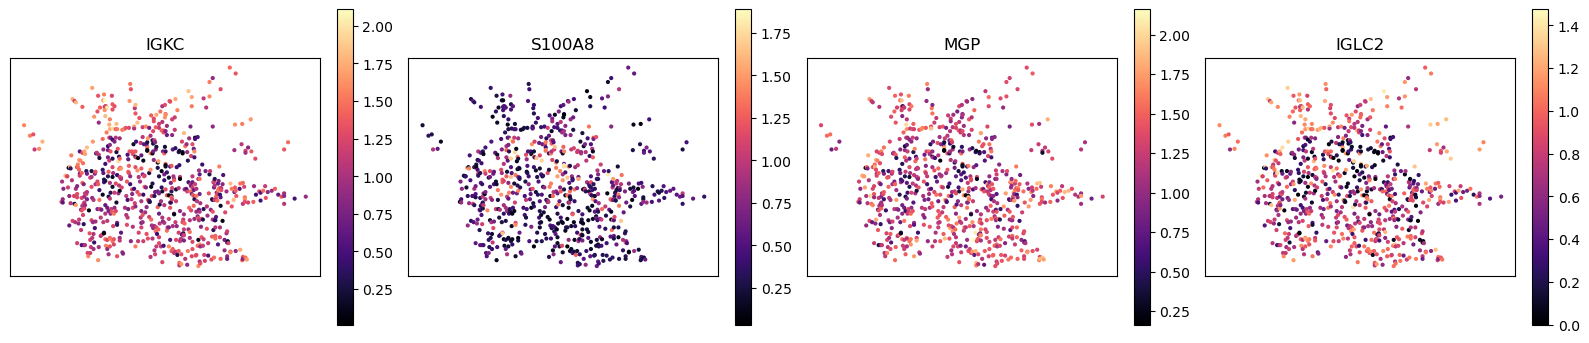

In [5]:
gene_cols = [c for c in tcga_pred.columns
             if c not in ('slide_name','x','y','grid_x','grid_y')]
if len(tcga_pred):
    variances = tcga_pred[gene_cols].var().sort_values(ascending=False)
    top_genes = variances.head(4).index.tolist()
    print('top-variance genes:', top_genes)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for ax, g in zip(axes, top_genes):
        sc = ax.scatter(tcga_pred['x'], tcga_pred['y'],
                        c=tcga_pred[g], s=4, cmap='magma')
        plt.colorbar(sc, ax=ax, fraction=0.046)
        ax.set_title(g); ax.invert_yaxis()
        ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout(); plt.show()
else:
    print('no TCGA tiles to plot')


## 4. Run on the HEST slide (spots mode) — parity check

NCBI776 has 4992 Visium spots after the paper's spot-selection. With the
canonical settings (`tile_size_px=183`, `edge_fraction_threshold=0.5`),
the companion should reproduce the paper's saved predictions.


In [6]:
hest_meta_pkl = Path(os.environ.get('P2S_HEST_META', 'hest_data/NCBI776_meta.pkl'))
if hest_meta_pkl.exists():
    hest_meta = pd.read_pickle(hest_meta_pkl)
    tile_size_hest = int(hest_meta.loc['NCBI776', 'pixels_btween_spots'])
else:
    tile_size_hest = 183  # value from st_validationmetadata_hest.pkl for NCBI776
print(f'HEST tile size: {tile_size_hest} px (MPP-standardized — must match paper)')

t0 = time.time()
hest_out = pipe.predict_spots(
    slide_path=HEST_SLIDE,
    spots=HEST_SPOTS,
    slide_name='NCBI776',
    tile_size_px=tile_size_hest,
    edge_fraction_threshold=0.5,   # matches 1main_MultiFMExtract.py
    smooth=False,
)
hest_pred = hest_out['pred']
print(f'HEST pred shape: {hest_pred.shape}   ({time.time()-t0:.1f}s)')
hest_pred.head(3)


HEST tile size: 183 px (MPP-standardized — must match paper)


/data/shulmaned/conda/envs/vision_ml/lib/python3.10/site-packages/torchvision/transforms/functional.py:475: UserWarning: Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.
  warnings.warn("Anti-alias option is always applied for PIL Image input. Argument antialias is ignored.")


HEST pred shape: (4296, 14073)   (163.1s)


,slide_name,x,y,grid_x,grid_y,AL627309.5,LINC01409,LINC01128,LINC00115,FAM41C,...,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB,AC011043.1,AC007325.4
spot_id,,,,,,,,,,,,,,,,,,,,,
NCBI776_1x127,NCBI776,3676.0,4798.0,1,2,0.000681,0.009733,0.003074,0.000104,0.0,...,1.739159,1.819615,1.584927,0.602686,1.717959,0.912704,0.027486,1.589588,0.001572,0.012392
NCBI776_3x127,NCBI776,3678.0,5116.0,1,4,0.001404,0.012272,0.001992,0.000855,0.0,...,1.834432,2.056117,1.619648,0.532584,1.858967,0.952695,0.010576,1.745712,0.001126,0.001933
NCBI776_5x127,NCBI776,3681.0,5434.0,1,5,0.001579,0.005932,0.003052,0.000214,0.0,...,1.804464,2.072532,1.559319,0.538878,1.833533,0.913853,0.019596,1.711475,0.002391,0.001273


### Compare against the paper's saved prediction for NCBI776


In [7]:
paper_pred = pd.read_pickle(HEST_PAPER)
print('paper pred shape:', paper_pred.shape)

common = paper_pred.index.intersection(hest_pred.index)
print(f'common spots: {len(common)}  (paper={len(paper_pred)}, companion={len(hest_pred)})')

gene_cols = [c for c in paper_pred.columns
             if c in hest_pred.columns
             and c not in ('slide_name','x','y','grid_x','grid_y')]
print(f'common genes: {len(gene_cols)}')

paper_a = paper_pred.loc[common, gene_cols].to_numpy(dtype=np.float64)
comp_a  = hest_pred.loc[common,  gene_cols].to_numpy(dtype=np.float64)

abs_diff = np.abs(paper_a - comp_a)
print(f'max abs diff       : {abs_diff.max():.3e}')
print(f'mean abs diff      : {abs_diff.mean():.3e}')
print(f'95th %ile abs diff : {np.percentile(abs_diff, 95):.3e}')
print(f'99th %ile abs diff : {np.percentile(abs_diff, 99):.3e}')

def per_gene_pearson(a, b):
    a = a - a.mean(axis=0, keepdims=True)
    b = b - b.mean(axis=0, keepdims=True)
    num = (a * b).sum(axis=0)
    den = np.sqrt((a**2).sum(axis=0) * (b**2).sum(axis=0))
    return np.where(den > 0, num / np.maximum(den, 1e-12), np.nan)

cors = per_gene_pearson(paper_a, comp_a)
valid = ~np.isnan(cors)
print(f'per-gene Pearson r — median={np.nanmedian(cors):.4f}, mean={np.nanmean(cors):.4f}')
print(f'frac genes r > 0.99 : {(cors[valid] > 0.99).mean():.3f}')
print(f'frac genes r > 0.999: {(cors[valid] > 0.999).mean():.3f}')


paper pred shape: (4295, 14071)
common spots: 4295  (paper=4295, companion=4296)
common genes: 14068


max abs diff       : 5.198e-01
mean abs diff      : 7.429e-03


95th %ile abs diff : 2.915e-02


99th %ile abs diff : 5.535e-02


per-gene Pearson r — median=0.9769, mean=0.9753
frac genes r > 0.99 : 0.002
frac genes r > 0.999: 0.000


### Distribution of per-gene Pearson r


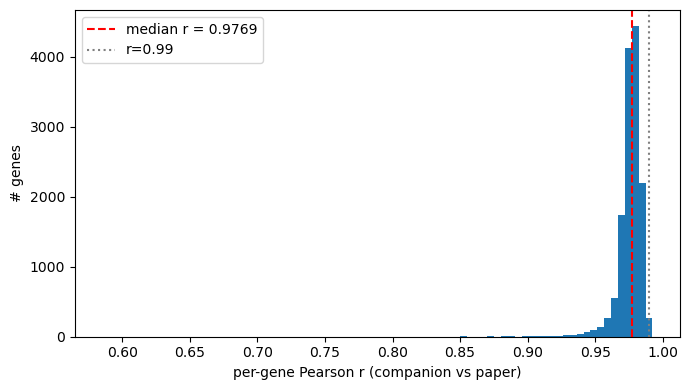

In [8]:
plt.figure(figsize=(7, 4))
plt.hist(cors[~np.isnan(cors)], bins=80)
plt.axvline(np.nanmedian(cors), color='red', linestyle='--', label=f'median r = {np.nanmedian(cors):.4f}')
plt.axvline(0.99, color='gray', linestyle=':', label='r=0.99')
plt.xlabel('per-gene Pearson r (companion vs paper)')
plt.ylabel('# genes')
plt.legend(); plt.tight_layout(); plt.show()


### Side-by-side spatial maps (best- and median-correlated genes)


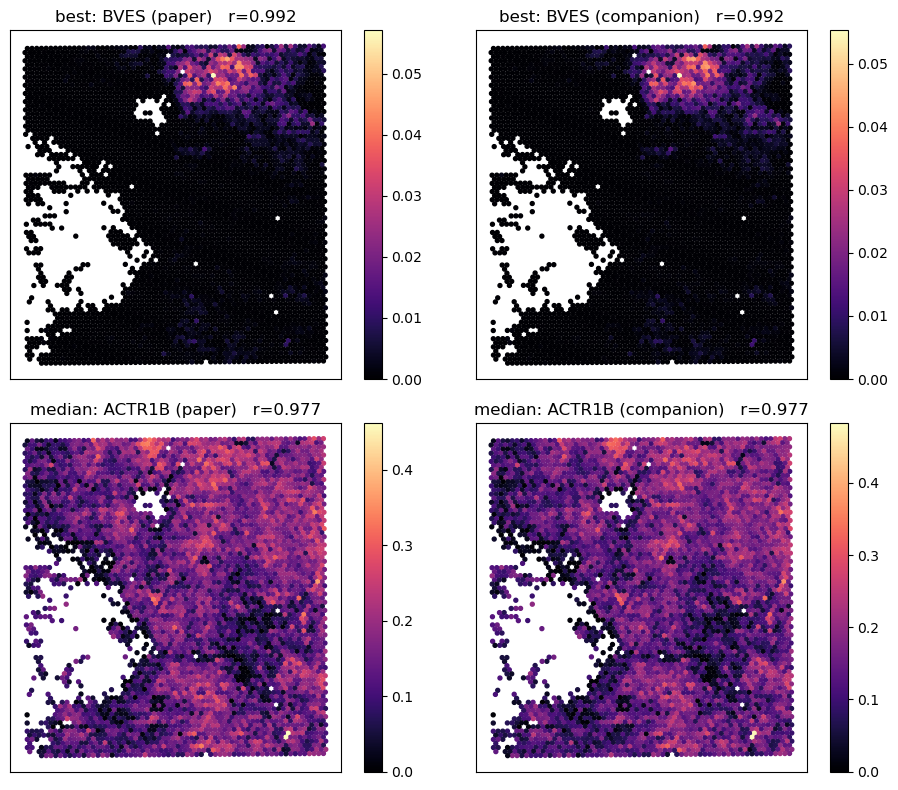

In [9]:
order = np.argsort(np.where(np.isnan(cors), -np.inf, cors))
best_idx   = int(order[-1])
median_idx = int(order[(~np.isnan(cors)).sum() // 2])
xs = hest_pred.loc[common, 'x'].to_numpy()
ys = hest_pred.loc[common, 'y'].to_numpy()

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for j, (idx, label) in enumerate([(best_idx, 'best'), (median_idx, 'median')]):
    gene = gene_cols[idx]; r = cors[idx]
    for i, (src_label, vec) in enumerate([('paper', paper_a[:, idx]), ('companion', comp_a[:, idx])]):
        ax = axes[j, i]
        sc = ax.scatter(xs, ys, c=vec, s=8, cmap='magma')
        plt.colorbar(sc, ax=ax, fraction=0.046)
        ax.set_title(f'{label}: {gene} ({src_label})   r={r:.3f}')
        ax.invert_yaxis(); ax.set_aspect('equal')
        ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()


## 5. Parity verdict

- **Bit-for-bit** (max abs diff < 1e-5, median r ≈ 1.0): companion reproduces
  the paper exactly.
- **Correlated but not bit-for-bit** (median r > 0.99): predictions are
  quantitatively close — typical sources are SPAMS stain-matrix version drift
  and float reduction order (we batch all tiles through each MLP; the
  reference loops one tile at a time).
- **Low median r (≪ 0.95)**: pipeline diverged. Double-check `tile_size_px`,
  `edge_fraction_threshold`, and the `pixel_x`/`pixel_y` convention in the
  spots file.
